# Laboratorio 2 · Trabajo grupal de interpretación

**Módulo III · Sesión 7 (avance) y Sesión 8 (cierre) · Clasificación y segmentación industrial**
**Modalidad:** seis grupos de trabajo · **Ponderación:** 10% del módulo · **Tiempo total recomendado:** 120 minutos

## Propósito

El grupo trabajará con un dataset de 900 observaciones de compresores, bombas y ventiladores para anticipar **fallas del siguiente turno** y para **segmentar regímenes operativos**. El código Python ya está preparado y ejecutado; no es el objetivo de la evaluación. La evidencia calificada es la capacidad del grupo para **leer resultados, justificar decisiones de modelado, traducir métricas a riesgo operativo y comunicar una recomendación defendible**.

> **Regla de trabajo:** ningún integrante se limita a "ejecutar el notebook". Todos deben revisar tablas, matrices y gráficos, discutir la evidencia y estar en condiciones de explicar cualquier respuesta del grupo. El docente puede pedir a cualquier integrante que explique una decisión.

> La entrega de la Sesión 7 es un avance (Parte A). La calificación final se asigna después de completar la Parte B (clustering) en la Sesión 8.

## Acuerdo de trabajo del grupo

Antes de ejecutar, registren el número de grupo y los integrantes en la celda siguiente. Pueden distribuir roles de apoyo —coordinación del tiempo, lectura de métricas, revisión del contrato de datos, interpretación de gráficos, control de validaciones y relatoría—, pero los roles no dividen el aprendizaje: **todos deben comprender el flujo completo**, desde el contrato predictivo hasta la segmentación.

La única entrega es este notebook ejecutado de principio a fin, con las tablas, matrices y gráficos visibles, más las respuestas del grupo en las celdas "Interpretación grupal". El código puede generar archivos CSV auxiliares para documentar la corrida, pero **no se entregan por separado**.

In [18]:
# 0. Identificación del grupo
# Cambien sólo la información de identificación; el resto del código ya está preparado.
NUMERO_GRUPO = "G6"  # Usen G1, G2, G3, G4, G5 o G6.
INTEGRANTES = [
    "Quenallata Rodríguez Paola Andrea",
    "Takusi Ávila Midori Margoth",
    "Zanca Rodríguez Richard Adrian",
    "Tucumán Alarcón Rembert Rodrigo",
    "Poka Yujra Eddy",
]

#assert NUMERO_GRUPO in {"G1", "G2", "G3", "G4", "G5", "G6"}, "Use un número de grupo válido (G1 a G6)."
#assert all(nombre.split(":", 1)[1].strip() for nombre in INTEGRANTES), "Complete el nombre de cada integrante."

print("Grupo:", NUMERO_GRUPO)
print("Integrantes:", ", ".join(INTEGRANTES))

Grupo: G6
Integrantes: Quenallata Rodríguez Paola Andrea, Takusi Ávila Midori Margoth, Zanca Rodríguez Richard Adrian, Tucumán Alarcón Rembert Rodrigo, Poka Yujra Eddy


## Situación problemática

La planta dispone de 900 observaciones de compresores, bombas y ventiladores. Cada registro integra variables térmicas, mecánicas y operativas. Mantenimiento necesita **anticipar fallas del siguiente turno** y **reconocer regímenes de operación** que permitan priorizar inspecciones sin detener innecesariamente la producción.

El dataset ya representa una **Capa Silver didáctica**, pero conserva faltantes controlados que el `Pipeline` trata mediante imputación. También contiene una variable posterior al evento (`orden_correctiva_post_evento`) diseñada para comprobar si el grupo identifica fuga de información.

**Pregunta de negocio:** ¿cómo detectar la mayor cantidad posible de fallas relevantes y segmentar los regímenes operativos sin confundir una alta exactitud con seguridad predictiva?

**Decisión protegida:** priorizar inspecciones sin convertir cada observación en una parada innecesaria. El modelo recomienda una inspección; no sustituye procedimientos, permisos de trabajo ni enclavamientos de seguridad certificados.

In [19]:
# 1. Librerías y configuración
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, confusion_matrix,
    ConfusionMatrixDisplay, classification_report,
    precision_score, recall_score, f1_score,
    silhouette_score,
)
from sklearn.cluster import KMeans

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid", palette="deep")

DATASET = "GIAD-M3-S07_Laboratorio_2_Dataset_Silver.csv"
candidatos = [
    Path(os.environ.get("LAB2_DATA_PATH", "")),
    Path("/content") / DATASET,
    Path.cwd() / DATASET,
]
RUTA = next((p for p in candidatos if str(p) and p.is_file()), None)
assert RUTA is not None, f"No se encontró {DATASET}. Súbalo a Colab o ubíquelo junto al notebook."
print("Dataset:", RUTA)

Dataset: /content/GIAD-M3-S07_Laboratorio_2_Dataset_Silver.csv


# PARTE A · SESIÓN 7 · CLASIFICACIÓN SUPERVISADA

## 2. Carga y auditoría del objetivo

Se carga el CSV y se audita `falla_proximo_turno`: dimensiones, tipos, faltantes por columna y distribución absoluta/relativa del objetivo. Se compara el accuracy de "predecir siempre la clase mayoritaria" contra la prevalencia real de fallas.

Dimensiones: (900, 15)

Tipos de dato:
registro_id                      object
timestamp_utc                    object
equipo_id                        object
familia_equipo                   object
zona_planta                      object
turno                            object
temperatura_c                   float64
vibracion_mm_s                  float64
presion_bar                     float64
corriente_a                     float64
carga_pct                       float64
horas_desde_mantenimiento       float64
alarmas_24h                       int64
orden_correctiva_post_evento     object
falla_proximo_turno               int64
dtype: object

Faltantes por columna:
registro_id                      0
timestamp_utc                    0
equipo_id                        0
familia_equipo                   0
zona_planta                      0
turno                            9
temperatura_c                   22
vibracion_mm_s                   0
presion_bar                     18
corrient

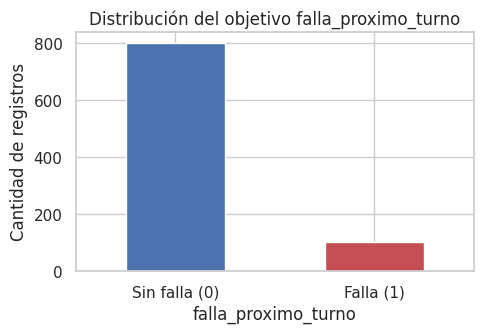

In [20]:
# 2.1-2.2: carga y auditoría (código ya resuelto).
df = pd.read_csv(RUTA)

print("Dimensiones:", df.shape)
print()
print("Tipos de dato:")
print(df.dtypes)
print()
print("Faltantes por columna:")
print(df.isna().sum())

TARGET = "falla_proximo_turno"
print()
print("Distribución absoluta del objetivo:")
print(df[TARGET].value_counts())
print()
print("Distribución relativa del objetivo:")
print(df[TARGET].value_counts(normalize=True).round(4))

prevalencia = df[TARGET].mean()
accuracy_mayoritaria = max(prevalencia, 1 - prevalencia)
print()
print(f"Prevalencia de la clase positiva (falla=1): {prevalencia:.4f} ({prevalencia:.2%})")
print(f"Accuracy de predecir siempre la clase mayoritaria (falla=0): {accuracy_mayoritaria:.4f} ({accuracy_mayoritaria:.2%})")

fig, ax = plt.subplots(figsize=(5, 3.5))
df[TARGET].value_counts().sort_index().plot(kind="bar", color=["#4C72B0", "#C44E52"], ax=ax)
ax.set_xticklabels(["Sin falla (0)", "Falla (1)"], rotation=0)
ax.set_ylabel("Cantidad de registros")
ax.set_title("Distribución del objetivo falla_proximo_turno")
plt.tight_layout()
plt.show()

### Interpretación grupal 1 — Prevalencia y accuracy engañoso

Con los resultados anteriores a la vista, respondan como grupo:

1. ¿Cuál es la prevalencia de la clase positiva y cuántos registros representa sobre 900?
2. ¿Qué accuracy obtendría un modelo que siempre predice "sin falla"? ¿Por qué esa cifra parece buena a simple vista?
3. ¿Por qué ese accuracy sería insuficiente como única métrica para decidir si el modelo sirve para mantenimiento?

**Respuesta del grupo:**

1. La prevalencia es del 11.33%, lo que equivale a 102 registros con falla de los 900 totales.
2. Obtendría un 88.67% de accuracy. Parece alta a simple vista porque casi 9 de cada 10 casos son acertados, pero es solo un reflejo del fuerte desbalance de clases.
3. Es insuficiente porque ese modelo tendría un recall de 0%, pasando por alto el 100% de las fallas reales que mantenimiento necesita prevenir.

### Interpretación grupal 2 — Contrato predictivo

Antes de entrenar cualquier modelo, el grupo debe fijar por escrito el contrato predictivo. Completen cada punto con una decisión concreta y justificada, no solo una palabra:

- **Clase positiva:** ...
- **Horizonte de predicción:** ...
- **Acción ante una alerta:** ...
- **Costo de un falso negativo (no detectar una falla real):** ...
- **Costo de un falso positivo (alertar sin que exista falla):** ...
- **Métrica primaria:** ...
- **Contramétrica o límite operativo (qué no debe empeorar):** ...

**Respuesta del grupo:**

- **Clase positiva:** Ocurrencia de falla en el equipo (falla_proximo_turno = 1), que es el evento crítico que se busca mitigar.
- **Horizonte de predicción:** El turno operativo inmediatamente posterior al momento de la medición.
- **Acción ante una alerta:** Priorizar y programar una inspección técnica preventiva en el equipo antes de iniciar el siguiente turno, sin detener la producción de forma innecesaria.
- **Costo de un falso negativo:** Crítico y muy elevado, pues provoca paradas imprevistas de planta, daños mecánicos graves y riesgos de seguridad al no advertir una falla real.
- **Costo de un falso positivo:** Bajo o moderado, limitándose al tiempo y recursos invertidos por el técnico en revisar un equipo que no iba a fallar.
- **Métrica primaria:** Recall (o Sensibilidad) de la clase positiva, ya que el objetivo principal del negocio es capturar la mayor cantidad de fallas reales posibles.
- **Contramétrica o límite operativo:** Precisión (o volumen total de alertas), asegurando que la cantidad de inspecciones no sature la capacidad operativa del personal de mantenimiento.

## 4. Variables, disponibilidad y fuga de información

Se define `X` e `y` a partir del diccionario de datos. Se excluyen los identificadores (`registro_id`, `timestamp_utc`, `equipo_id`) y la variable posterior al evento (`orden_correctiva_post_evento`), que constituye una fuga deliberada de información.

In [21]:
# 4. Variables, X e y (código ya resuelto).
TARGET = "falla_proximo_turno"
IDENTIFICADORES = ["registro_id", "timestamp_utc", "equipo_id"]
FUGAS = ["orden_correctiva_post_evento"]

variables_predictoras = [c for c in df.columns if c not in IDENTIFICADORES + FUGAS + [TARGET]]
X = df[variables_predictoras].copy()
y = df[TARGET].copy()

print("Variables predictoras:", variables_predictoras)
print("X shape:", X.shape, " y shape:", y.shape)

Variables predictoras: ['familia_equipo', 'zona_planta', 'turno', 'temperatura_c', 'vibracion_mm_s', 'presion_bar', 'corriente_a', 'carga_pct', 'horas_desde_mantenimiento', 'alarmas_24h']
X shape: (900, 10)  y shape: (900,)


### Interpretación grupal 3 — Justificación de disponibilidad

1. ¿Por qué `orden_correctiva_post_evento` se excluye de `X`? Usen el diccionario de datos para justificar la respuesta en términos de "disponible antes vs. después del horizonte".
2. ¿Por qué `registro_id`, `timestamp_utc` y `equipo_id` tampoco entran como variables predictoras, aunque estén disponibles antes del horizonte?
3. Si por error se hubiera incluido `orden_correctiva_post_evento` en `X`, ¿qué le pasaría a las métricas del modelo y por qué esa mejora sería una señal de alarma y no un logro?

**Respuesta del grupo:**

1. Se excluye porque es una variable generada después de que la falla ya ocurrió. Incluirla violaría el principio de disponibilidad temporal al no existir dicha información al momento de anticipar el siguiente turno
2. No se incluyen porque son metadatos e identificadores de alta cardinalidad. Su presencia provocaría que el modelo memorice registros o equipos específicos en lugar de aprender patrones físicos y operativos generalizables.
3. Las métricas subirían artificialmente a niveles casi perfectos (~100%). Esto sería una alarma crítica y no un logro porque revelaría una fuga de datos que inutilizaría el modelo en un entorno real de producción al no contar con esa variable a tiempo.

## 5. Partición estratificada y baseline

Se reserva 20% para test con `random_state=42` y `stratify=y`, de modo que la prevalencia de fallas se conserve en ambas particiones. Se entrena un `DummyClassifier(strategy="most_frequent")` como baseline: un modelo que ignora las variables y siempre predice la clase mayoritaria.

In [22]:
# 5. Partición y baseline (código ya resuelto).
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print("X_train:", X_train.shape, " X_test:", X_test.shape)
print(f"Prevalencia train: {y_train.mean():.4f}   Prevalencia test: {y_test.mean():.4f}")

baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)
y_pred_base = baseline.predict(X_test)

print()
print("Baseline — accuracy:", round(accuracy_score(y_test, y_pred_base), 4))
print("Baseline — balanced accuracy:", round(balanced_accuracy_score(y_test, y_pred_base), 4))
print("Baseline — matriz de confusión:")
print(confusion_matrix(y_test, y_pred_base))
print()
print("Baseline — classification_report:")
print(classification_report(y_test, y_pred_base, zero_division=0))

X_train: (720, 10)  X_test: (180, 10)
Prevalencia train: 0.1139   Prevalencia test: 0.1111

Baseline — accuracy: 0.8889
Baseline — balanced accuracy: 0.5
Baseline — matriz de confusión:
[[160   0]
 [ 20   0]]

Baseline — classification_report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       160
           1       0.00      0.00      0.00        20

    accuracy                           0.89       180
   macro avg       0.44      0.50      0.47       180
weighted avg       0.79      0.89      0.84       180



### Interpretación grupal 4 — Partición estratificada y por qué el baseline no protege la decisión

1. ¿Por qué la partición se hizo con `stratify=y` en vez de un `train_test_split` simple? Comparen la prevalencia impresa en train y en test: ¿qué le hubiera podido pasar a esa proporción de fallas en test si la partición no se hubiera estratificado?
2. ¿Cuántas fallas reales detecta el baseline en test (revisen la matriz de confusión) y qué recall tiene sobre la clase positiva?
3. El baseline logra una accuracy alta. ¿Por qué esa cifra no significa que el baseline sea útil para mantenimiento?
4. ¿Qué le pasaría a la planta si Mantenimiento usara el baseline como si fuera un modelo predictivo real?

**Respuesta del grupo:**

1. Se usó stratify=y para asegurar que tanto train (11.39%) como test (11.11%) tengan exactamente la misma proporción de fallas. Si no se estratificaba, el azar podía dejar a test con muy pocas o ninguna falla, impidiendo evaluar el modelo con datos realistas.
2. El baseline detecta 0 fallas en test (acierta 160 casos sin falla y falla en las 20 averías reales). Por lo tanto, su recall en la clase positiva es de 0.00 (0%).
3. Su accuracy es alto (88.89%) únicamente porque la gran mayoría de las máquinas no falla. No sirve para mantenimiento porque acierta por descarte sin haber anticipado un solo problema.
4. La planta sufriría paradas no programadas constantes y posibles daños graves en los equipos. Al asumir que "nunca pasa nada", las 20 fallas reales ocurrirían en plena operación sin previo aviso.

## 6. Pipeline reproducible

Dentro de un `ColumnTransformer`, las variables numéricas se imputan con la mediana y se escalan con `StandardScaler`; las categóricas se imputan con la moda y se codifican con `OneHotEncoder(handle_unknown="ignore")`. El estimador es una `LogisticRegression(max_iter=2000)`. Todo el preprocesamiento vive dentro del `Pipeline`, por lo que se ajusta solo con `train`.

In [23]:
# 6. Pipeline (código ya resuelto).
numericas = X.select_dtypes(include=[np.number]).columns.tolist()
categoricas = X.select_dtypes(exclude=[np.number]).columns.tolist()
print("Variables numéricas:", numericas)
print("Variables categóricas:", categoricas)

preprocesador = ColumnTransformer(transformers=[
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]), numericas),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), categoricas),
])

pipe = Pipeline([
    ("preprocesador", preprocesador),
    ("modelo", LogisticRegression(max_iter=2000)),
])
print()
print(pipe)

Variables numéricas: ['temperatura_c', 'vibracion_mm_s', 'presion_bar', 'corriente_a', 'carga_pct', 'horas_desde_mantenimiento', 'alarmas_24h']
Variables categóricas: ['familia_equipo', 'zona_planta', 'turno']

Pipeline(steps=[('preprocesador',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['temperatura_c',
                                                   'vibracion_mm_s',
                                                   'presion_bar', 'corriente_a',
                                                   'carga_pct',
                                                   'horas_desde_manteni

### Interpretación grupal 5 — Por qué ajustar dentro del Pipeline

1. ¿Qué pasaría si la mediana de imputación y el `StandardScaler` se calcularan sobre todo el dataset (train + test) antes de dividir, en vez de ajustarse solo con `train` dentro del `Pipeline`?
2. ¿Por qué esa contaminación es difícil de detectar simplemente mirando las métricas finales?

**Respuesta del grupo:**

1. Se produciría contaminación o fuga de información (data leakage), ya que el modelo aprendería con datos calculados a partir de información del conjunto de prueba (test) que en la realidad aún no debería conocer.
2. Porque no genera errores de código y las métricas finales se ven normales o falsamente optimistas; el verdadero problema solo se hace evidente cuando el modelo falla al operar con datos nuevos en producción.

## 7. Ajuste de hiperparámetros

Se usa `StratifiedKFold(5, shuffle=True, random_state=42)` y `GridSearchCV` **solo sobre train**, comparando cuatro valores de `C` y `class_weight` igual a `None` o `"balanced"`. La métrica de selección es `balanced_accuracy`, coherente con una clase positiva minoritaria.

In [24]:
# 7. GridSearchCV (código ya resuelto).
param_grid = {
    "modelo__C": [0.05, 0.2, 1.0, 5.0],
    "modelo__class_weight": [None, "balanced"],
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(pipe, param_grid, scoring="balanced_accuracy", cv=cv, n_jobs=-1)
grid.fit(X_train, y_train)

print("Mejor combinación (best_params_):", grid.best_params_)
print("Mejor balanced_accuracy en CV (best_score_):", round(grid.best_score_, 4))
print()
print("Tabla completa de resultados de la búsqueda:")
resultados_cv = pd.DataFrame(grid.cv_results_)[
    ["param_modelo__C", "param_modelo__class_weight", "mean_test_score", "std_test_score", "rank_test_score"]
].sort_values("rank_test_score")
print(resultados_cv.to_string(index=False))

best_model = grid.best_estimator_

Mejor combinación (best_params_): {'modelo__C': 0.05, 'modelo__class_weight': 'balanced'}
Mejor balanced_accuracy en CV (best_score_): 0.8414

Tabla completa de resultados de la búsqueda:
 param_modelo__C param_modelo__class_weight  mean_test_score  std_test_score  rank_test_score
            0.05                   balanced         0.841408        0.039186                1
            1.00                   balanced         0.835152        0.030085                2
            0.20                   balanced         0.833596        0.031568                3
            5.00                   balanced         0.828109        0.027279                4
            5.00                       None         0.772337        0.059434                5
            1.00                       None         0.766455        0.059999                6
            0.20                       None         0.743391        0.082897                7
            0.05                       None         0.721115

### Interpretación grupal 6 — Estabilidad y elección de hiperparámetros

1. ¿Qué combinación de `C` y `class_weight` ganó la búsqueda y qué `balanced_accuracy` promedio obtuvo en validación cruzada?
2. Comparen la desviación estándar (`std_test_score`) entre las combinaciones con `class_weight="balanced"` y las combinaciones con `class_weight=None`. ¿Qué grupo es más estable entre folds?
3. ¿Por qué `class_weight="balanced"` tiende a ganar en un dataset con solo 11,3% de fallas, en vez del modelo sin ponderar?

**Respuesta del grupo:**

1. Ganó la combinación de C = 0.05 con class_weight = "balanced", alcanzando un balanced accuracy promedio de 0.8414 (84.14%) en validación cruzada.
2. Los modelos con class_weight="balanced" tienen desviaciones estándar más bajas (0.027 a 0.039) que los modelos con None (0.059 a 0.091). Por lo tanto, el grupo con balanced es mucho más estable y consistente entre los folds.
3. Porque al haber tan pocas fallas (11.3%), el modelo normal tiende a ignorarlas para no equivocarse; en cambio, balanced castiga con mayor fuerza no predecir una falla real, obligando al modelo a prestar atención a la clase minoritaria.

## 8. Evaluación aislada en test

El diseño seleccionado se evalúa **una sola vez** sobre test, que permaneció aislado durante toda la búsqueda. Se muestran matriz de confusión, soporte por clase y las métricas principales, sin esconder falsos positivos y falsos negativos detrás de un promedio global.

Matriz de confusión (filas=real, columnas=predicho):
[[146  14]
 [  1  19]]
Soporte por clase (0, 1): [160  20]

Accuracy:          0.9167
Balanced accuracy:  0.9312
Precision (clase 1): 0.5758
Recall (clase 1):    0.9500
F1 (clase 1):        0.7170

classification_report:
              precision    recall  f1-score   support

           0       0.99      0.91      0.95       160
           1       0.58      0.95      0.72        20

    accuracy                           0.92       180
   macro avg       0.78      0.93      0.83       180
weighted avg       0.95      0.92      0.93       180



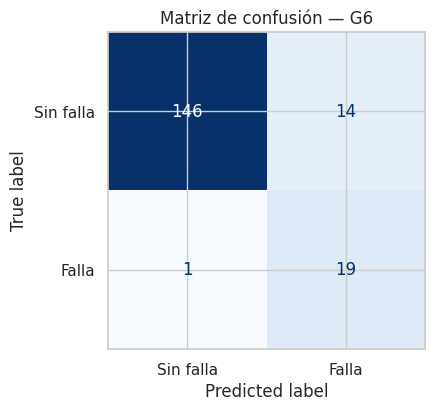

In [25]:
# 8. Evaluación en test (código ya resuelto).
y_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

print("Matriz de confusión (filas=real, columnas=predicho):")
print(cm)
print("Soporte por clase (0, 1):", np.bincount(y_test))
print()
print(f"Accuracy:          {accuracy_score(y_test, y_pred):.4f}")
print(f"Balanced accuracy:  {balanced_accuracy_score(y_test, y_pred):.4f}")
print(f"Precision (clase 1): {precision_score(y_test, y_pred):.4f}")
print(f"Recall (clase 1):    {recall_score(y_test, y_pred):.4f}")
print(f"F1 (clase 1):        {f1_score(y_test, y_pred):.4f}")
print()
print("classification_report:")
print(classification_report(y_test, y_pred, zero_division=0))

fig, ax = plt.subplots(figsize=(4.5, 4.5))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Sin falla", "Falla"]).plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"Matriz de confusión — {NUMERO_GRUPO}")
plt.tight_layout()
plt.show()

### Interpretación grupal 7 — Costo del error

1. **Falsos negativos:** ¿cuántos hay en la matriz de confusión? ¿Qué implica cada uno para la planta (una falla real que no se detectó)?
2. **Falsos positivos:** ¿cuántos hay? ¿Qué implica cada uno en términos de inspecciones innecesarias?
3. Con 180 observaciones en test y este resultado, ¿la solución respeta la capacidad real de inspección de una planta (revisen cuántas alertas totales genera)?
4. ¿Qué limitación importante permanece incluso con este modelo ajustado?

**Respuesta del grupo:**

1. Hay 1 falso negativo. Para la planta implica una falla real no anticipada, lo que se traduce en una parada no programada, sobrecostos de reparación urgente o posibles riesgos operativos.
2. Hay 14 falsos positivos. Cada uno representa una orden de inspección preventiva despachada a un equipo que estaba funcionando bien, consumiendo tiempo y horas-hombre innecesarias de los técnicos.
3. Sí, la solución es viable operativamente porque genera 33 alertas en total (19 fallas reales detectadas + 14 falsas alarmas) sobre 180 equipos evaluados, un volumen manejable para la cuadrilla de mantenimiento.
4. La limitación principal es la precisión moderada (57.58%): casi 4 de cada 10 alertas emitidas siguen siendo falsas alarmas, lo que a largo plazo puede causar desconfianza o "fatiga de alertas" en el personal de planta.

## 9. Sensibilidad al umbral

El modelo entrega una probabilidad, no solo una etiqueta. Se compara el desempeño con umbrales 0.35, 0.50 (por defecto) y 0.80 para mostrar el costo de mover la frontera de decisión.

In [26]:
# 9. Sensibilidad al umbral (código ya resuelto).
probs = best_model.predict_proba(X_test)[:, 1]
filas = []
for umbral in [0.35, 0.50, 0.80]:
    pred_u = (probs >= umbral).astype(int)
    cmu = confusion_matrix(y_test, pred_u)
    tn, fp, fn, tp = cmu.ravel()
    filas.append({
        "umbral": umbral, "TN": tn, "FP": fp, "FN": fn, "TP": tp,
        "precision": round(precision_score(y_test, pred_u, zero_division=0), 4),
        "recall": round(recall_score(y_test, pred_u, zero_division=0), 4),
        "f1": round(f1_score(y_test, pred_u, zero_division=0), 4),
        "alertas_totales": fp + tp,
    })
tabla_umbral = pd.DataFrame(filas)
print(tabla_umbral.to_string(index=False))

 umbral  TN  FP  FN  TP  precision  recall     f1  alertas_totales
   0.35 138  22   1  19     0.4634    0.95 0.6230               41
   0.50 146  14   1  19     0.5758    0.95 0.7170               33
   0.80 155   5   3  17     0.7727    0.85 0.8095               22


### Interpretación grupal 8 — Sensibilidad al umbral

1. Al bajar el umbral de 0.50 a 0.35, ¿qué costo aumenta y cuál disminuye? Usen las columnas FP, FN y alertas_totales de la tabla.
2. Al subir el umbral de 0.50 a 0.80, ¿qué costo aumenta y cuál disminuye?
3. Si Mantenimiento solo puede atender 25 alertas por corte de test sin saturarse, ¿qué umbral de los tres recomendaría el grupo y por qué?
4. ¿Por qué no sería correcto elegir un umbral únicamente porque produce la cifra de F1 más alta, sin considerar la capacidad de inspección?

**Respuesta del grupo:**

1. Aumenta el costo operativo por inspecciones innecesarias (los FP suben de 14 a 22 y las alertas totales pasan de 33 a 41). En cambio, el costo por riesgo no varía (los FN se mantienen en 1, conservando un recall de 0.95).
2. Aumenta el costo por riesgo de falla no detectada (los FN suben de 1 a 3, bajando el recall de 0.95 a 0.85). Disminuye el costo de inspecciones inútiles (los FP caen drásticamente de 14 a 5 y las alertas totales se reducen a 22).
3. Se recomendaría el umbral 0.80, ya que genera 22 alertas totales, siendo el único que no sobrepasa el límite de 25 inspecciones de la planta. Permite detectar el 85% de las fallas reales con una alta precisión del 77.27% sin saturar a los técnicos.
4. Porque el puntaje F1 es un promedio armónico puramente matemático que no toma en cuenta los recursos humanos ni el tiempo disponible del equipo de mantenimiento. Si un umbral da el mejor F1 pero genera más alertas de las que los técnicos pueden revisar, el modelo colapsará la operación en la práctica.

## 10. Evidencia de avance de la Sesión 7

Antes de cerrar la Sesión 7, el notebook debe contener, con salidas visibles:

- [ ] Interpretación grupal 1 y 2 (prevalencia y contrato predictivo).
- [ ] Interpretación grupal 3 (variables sin fuga).
- [ ] Interpretación grupal 4 (partición estratificada y baseline).
- [ ] Interpretación grupal 5 (Pipeline sin contaminación).
- [ ] Interpretación grupal 6 (estabilidad de GridSearchCV).
- [ ] Interpretación grupal 7 (costo del error en test).
- [ ] Interpretación grupal 8 (sensibilidad al umbral).

Guarden el notebook con salidas visibles. **Este checkpoint es parte del Laboratorio 2 y no genera una nota adicional**; la calificación final se asigna al cerrar la Parte B en la Sesión 8.

# PARTE B · SESIÓN 8 · CLUSTERING Y CIERRE

> Esta sección se desarrolla en la Sesión 8, con la guía del docente.

## 11. Preparación no supervisada

Para segmentar regímenes operativos se usan únicamente variables numéricas operativas. Se excluyen `falla_proximo_turno` (el objetivo), los identificadores y la variable posterior al evento. Las variables se imputan con la mediana y se estandarizan antes de aplicar K-Means, para que la distancia no quede dominada por variables de mayor magnitud (por ejemplo, `horas_desde_mantenimiento` frente a `carga_pct`).

In [27]:
# 11. Preparación no supervisada (código ya resuelto).
EXCLUIR_CLUSTER = IDENTIFICADORES + FUGAS + [TARGET]
numericas_cluster = [c for c in df.select_dtypes(include=[np.number]).columns if c not in EXCLUIR_CLUSTER]
print("Variables numéricas para clustering:", numericas_cluster)

Xc = df[numericas_cluster].copy()
imputer_c = SimpleImputer(strategy="median")
scaler_c = StandardScaler()
Xc_imputado = imputer_c.fit_transform(Xc)
Xc_escalado = scaler_c.fit_transform(Xc_imputado)
print("Matriz preparada para K-Means:", Xc_escalado.shape)

Variables numéricas para clustering: ['temperatura_c', 'vibracion_mm_s', 'presion_bar', 'corriente_a', 'carga_pct', 'horas_desde_mantenimiento', 'alarmas_24h']
Matriz preparada para K-Means: (900, 7)


### Interpretación grupal 9 — Por qué el objetivo no entra al clustering

1. ¿Por qué `falla_proximo_turno` no puede usarse como variable de entrada para K-Means, aunque después sí se use para describir los clusters?
2. ¿Qué pasaría con la interpretación de los segmentos si el objetivo se hubiera incluido en `Xc`?

**Respuesta del grupo:**

1. …
2. …

## 12. Selección de k y perfil de clusters

Se compara `k=2` a `k=6` mediante inercia y silhouette. Después de formar los clusters, se usa el objetivo **únicamente para describir** —no para entrenar— la tasa de falla de cada segmento. Se perfilan explícitamente dos soluciones: la de mejor silhouette (`k=2`) y `k=3`, para discutir el trade-off entre separación estadística e interpretabilidad operativa.

 k  inercia  silhouette
 2  4182.82      0.3082
 3  3329.56      0.2857
 4  2866.62      0.2592
 5  2591.97      0.2410
 6  2389.06      0.2429


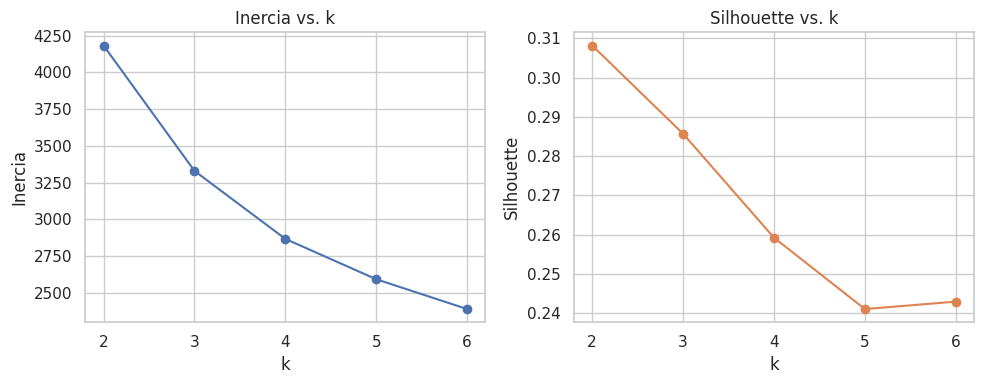

In [28]:
# 12. Selección de k (código ya resuelto).
resultados_k = []
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    etiquetas = km.fit_predict(Xc_escalado)
    resultados_k.append({
        "k": k,
        "inercia": round(km.inertia_, 2),
        "silhouette": round(silhouette_score(Xc_escalado, etiquetas), 4),
    })
tabla_k = pd.DataFrame(resultados_k)
print(tabla_k.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(tabla_k["k"], tabla_k["inercia"], marker="o", color="#4C72B0")
axes[0].set_title("Inercia vs. k")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inercia")
axes[1].plot(tabla_k["k"], tabla_k["silhouette"], marker="o", color="#DD8452")
axes[1].set_title("Silhouette vs. k")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette")
plt.tight_layout()
plt.show()

In [29]:
# Perfil con k=2 (mejor silhouette).
km2 = KMeans(n_clusters=2, random_state=42, n_init=10)
df["cluster_k2"] = km2.fit_predict(Xc_escalado)
sil_k2 = silhouette_score(Xc_escalado, df["cluster_k2"])
print(f"k=2 — silhouette: {sil_k2:.4f}")

perfil_k2 = df.groupby("cluster_k2").agg(
    n=("cluster_k2", "size"),
    tasa_falla=(TARGET, "mean"),
    temperatura_media=("temperatura_c", "mean"),
    vibracion_media=("vibracion_mm_s", "mean"),
    presion_media=("presion_bar", "mean"),
    corriente_media=("corriente_a", "mean"),
    carga_media=("carga_pct", "mean"),
    horas_mantenimiento_media=("horas_desde_mantenimiento", "mean"),
    alarmas_media=("alarmas_24h", "mean"),
).round(3).reset_index()
print(perfil_k2.to_string(index=False))

k=2 — silhouette: 0.3082
 cluster_k2   n  tasa_falla  temperatura_media  vibracion_media  presion_media  corriente_media  carga_media  horas_mantenimiento_media  alarmas_media
          0 492       0.012             69.251            3.437          5.334           79.113       64.476                    132.543          0.250
          1 408       0.235             77.904            5.265          5.358           97.617       84.548                    320.945          1.176


k=3 — silhouette: 0.2857
 cluster_k3   n  tasa_falla  temperatura_media  vibracion_media  presion_media  corriente_media  carga_media  horas_mantenimiento_media  alarmas_media
          0 438       0.009             68.603            3.454          5.092           77.619       63.050                    134.025          0.249
          1 325       0.062             76.923            4.239          6.145           98.280       85.132                    188.534          0.665
          2 137       0.569             78.862            6.921          4.255           93.906       79.811                    556.062          2.029


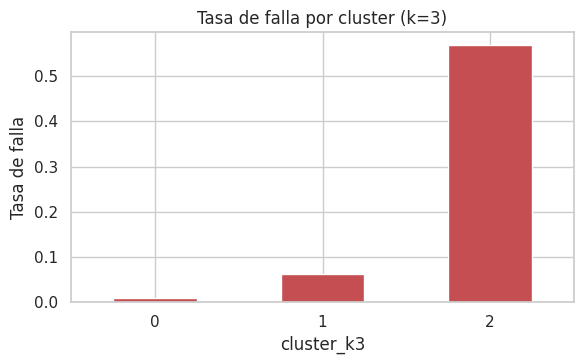

In [30]:
# Perfil con k=3 (alternativa operativa).
km3 = KMeans(n_clusters=3, random_state=42, n_init=10)
df["cluster_k3"] = km3.fit_predict(Xc_escalado)
sil_k3 = silhouette_score(Xc_escalado, df["cluster_k3"])
print(f"k=3 — silhouette: {sil_k3:.4f}")

perfil_k3 = df.groupby("cluster_k3").agg(
    n=("cluster_k3", "size"),
    tasa_falla=(TARGET, "mean"),
    temperatura_media=("temperatura_c", "mean"),
    vibracion_media=("vibracion_mm_s", "mean"),
    presion_media=("presion_bar", "mean"),
    corriente_media=("corriente_a", "mean"),
    carga_media=("carga_pct", "mean"),
    horas_mantenimiento_media=("horas_desde_mantenimiento", "mean"),
    alarmas_media=("alarmas_24h", "mean"),
).round(3).reset_index()
print(perfil_k3.to_string(index=False))

fig, ax = plt.subplots(figsize=(6, 3.8))
perfil_k3.set_index("cluster_k3")["tasa_falla"].plot(kind="bar", color="#C44E52", ax=ax)
ax.set_title("Tasa de falla por cluster (k=3)")
ax.set_xlabel("cluster_k3")
ax.set_ylabel("Tasa de falla")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

### Interpretación grupal 10 — Selección de k y trade-off operativo

1. ¿Qué valor de k tiene el mejor silhouette? ¿Qué significa un silhouette más alto en términos de separación entre clusters?
2. Con `k=3`, uno de los clusters concentra una tasa de falla mucho mayor que los otros dos. Identifiquen ese cluster: ¿cuántas observaciones tiene y cuál es su tasa de falla?
3. Aunque `k=2` tiene mejor silhouette que `k=3`, ¿por qué un equipo de mantenimiento podría preferir trabajar con la segmentación de `k=3`? Apóyense en los perfiles (horas desde mantenimiento, alarmas, vibración).
4. ¿Es correcto decir que un silhouette más bajo siempre significa una segmentación "peor"? Justifiquen la respuesta considerando el objetivo operativo, no solo la métrica.

**Respuesta del grupo:**

1. …
2. …
3. …
4. …

## 13. Validación y reproducibilidad

Las validaciones comprueban que el flujo completo corre de principio a fin y que las cifras reportadas por el grupo coinciden con la corrida real (no deben transcribirse de otra fuente).

In [31]:
# Validación y reproducibilidad (código ya resuelto).
assert df.shape[0] == 900 and df.shape[1] in (15, 16, 17), "La carga del dataset no coincide con el archivo entregado."
assert TARGET not in variables_predictoras, "El objetivo no debe estar entre las variables predictoras."
assert "orden_correctiva_post_evento" not in variables_predictoras, "La variable de fuga no debe entrar a X."
assert set(IDENTIFICADORES).isdisjoint(variables_predictoras), "Los identificadores no deben entrar a X."
assert X_train.shape[0] == 720 and X_test.shape[0] == 180, "La partición 80/20 no coincide con lo esperado."
assert abs(y_test.mean() - y.mean()) < 0.03, "La estratificación no conservó la prevalencia en test."
assert grid.best_params_["modelo__class_weight"] == "balanced", "Verifique la búsqueda de hiperparámetros."
assert recall_score(y_test, y_pred) > 0.90, "El recall del modelo seleccionado debe superar 0.90."
assert TARGET not in numericas_cluster, "El objetivo no debe usarse para entrenar K-Means."
assert len(tabla_k) == 5, "Deben evaluarse k=2 a k=6."
print("✓ Todas las validaciones fueron superadas.")

✓ Todas las validaciones fueron superadas.


### Interpretación grupal 11 — Cierre técnico y recomendación de planta

Con toda la evidencia generada, el grupo redacta su cierre:

- **Modelo supervisado recomendado y por qué:** ...
- **Umbral recomendado y capacidad de inspección que exige:** ...
- **Número de clusters elegido para producción (k=2 o k=3) y justificación:** ...
- **Segmento prioritario y qué lo distingue:** ...
- **Recomendación concreta para Mantenimiento:** ...
- **Dos limitaciones del análisis:**
  1. ...
  2. ...
- **Dos recomendaciones para mejorar el modelo o los datos antes de producción:**
  1. ...
  2. ...

**Respuesta del grupo:**

- **Modelo supervisado recomendado y por qué:** …
- **Umbral recomendado y capacidad de inspección que exige:** …
- **Número de clusters elegido para producción y justificación:** …
- **Segmento prioritario y qué lo distingue:** …
- **Recomendación concreta para Mantenimiento:** …
- **Dos limitaciones del análisis:**
  1. …
  2. …
- **Dos recomendaciones para mejorar el modelo o los datos antes de producción:**
  1. …
  2. …

## 14. Cierre y entrega

El código puede exportar las predicciones de test y el perfil de clusters para documentar la corrida. Estos archivos son **salidas auxiliares y no se entregan por separado**. La única entrega es este notebook ejecutado, con las tablas, matrices y gráficos visibles, más las respuestas del grupo en Markdown.

In [32]:
# Exportación auxiliar (opcional; no es un entregable separado).
SALIDA_DIR = Path(os.environ.get("LAB2_OUTPUT_DIR", "salidas_lab2"))
SALIDA_DIR.mkdir(parents=True, exist_ok=True)

predicciones = X_test.copy()
predicciones["real"] = y_test.values
predicciones["prediccion"] = y_pred
predicciones["probabilidad"] = probs
ruta_predicciones = SALIDA_DIR / f"Laboratorio_2_{NUMERO_GRUPO}_Predicciones.csv"
predicciones.to_csv(ruta_predicciones, index=False, encoding="utf-8-sig")

ruta_perfiles = SALIDA_DIR / f"Laboratorio_2_{NUMERO_GRUPO}_Perfiles_Cluster.csv"
perfil_k3.to_csv(ruta_perfiles, index=False, encoding="utf-8-sig")

print("Archivos auxiliares generados (no son entregables separados):")
for ruta in [ruta_predicciones, ruta_perfiles]:
    print(" -", ruta)

Archivos auxiliares generados (no son entregables separados):
 - salidas_lab2/Laboratorio_2_G6_Predicciones.csv
 - salidas_lab2/Laboratorio_2_G6_Perfiles_Cluster.csv


## Evidencia de participación de todos los integrantes

Antes de entregar, cada integrante debe indicar qué interpretación ayudó a construir. Esta evidencia no reemplaza la interpretación grupal: demuestra que todos participaron en ella.

| Integrante | Aporte explicado por la persona | Evidencia revisada |
|---|---|---|
| … | … | … |
| … | … | … |
| … | … | … |
| … | … | … |
| … | … | … |

## Checklist grupal antes de entregar

- [ ] El grupo ejecutó el notebook de principio a fin (Restart and run all).
- [ ] Todos los integrantes revisaron tablas, matrices y gráficos.
- [ ] Las 11 interpretaciones grupales están completas, sin puntos suspensivos.
- [ ] El objetivo y los identificadores no entraron a X ni a la matriz de clustering.
- [ ] Se justificó la elección del umbral y del número de clusters (k=2 vs. k=3).
- [ ] Se documentaron dos limitaciones y dos recomendaciones.
- [ ] La única entrega es el notebook `Grupo_XX_Laboratorio_2.ipynb`; los CSV no se entregan por separado.